In [6]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ── paths ──────────────────────────────────────────────────────────────
ROOT      = Path().resolve().parent
DB_PATH   = ROOT / "data" / "processed" / "credit_risk.duckdb"
FIG_DIR   = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

conn = duckdb.connect(str(DB_PATH))

# ── plot style ──────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi"      : 150,
    "figure.figsize"  : (10, 5),
    "axes.titlesize"  : 13,
    "axes.labelsize"  : 11,
    "axes.spines.top" : False,
    "axes.spines.right": False,
})

print("Connected. Ready for EDA.")

Connected. Ready for EDA.


In [7]:
df = conn.execute("SELECT * FROM staging.loans").df()
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nBad rate: {df['is_bad'].mean():.2%}")

Shape: (1369566, 35)

Dtypes:
id                                     int64
loan_amnt                            float64
funded_amnt                          float64
term_months                            int32
int_rate                             float32
installment                          float64
grade                                 object
sub_grade                             object
emp_length_yrs                         Int32
home_ownership                        object
annual_inc                           float64
verification_status                   object
purpose                               object
addr_state                            object
dti                                  float64
delinq_2yrs                          float64
fico_range_low                       float64
fico_range_high                      float64
fico_avg                             float64
inq_last_6mths                       float64
open_acc                             float64
pub_rec                  

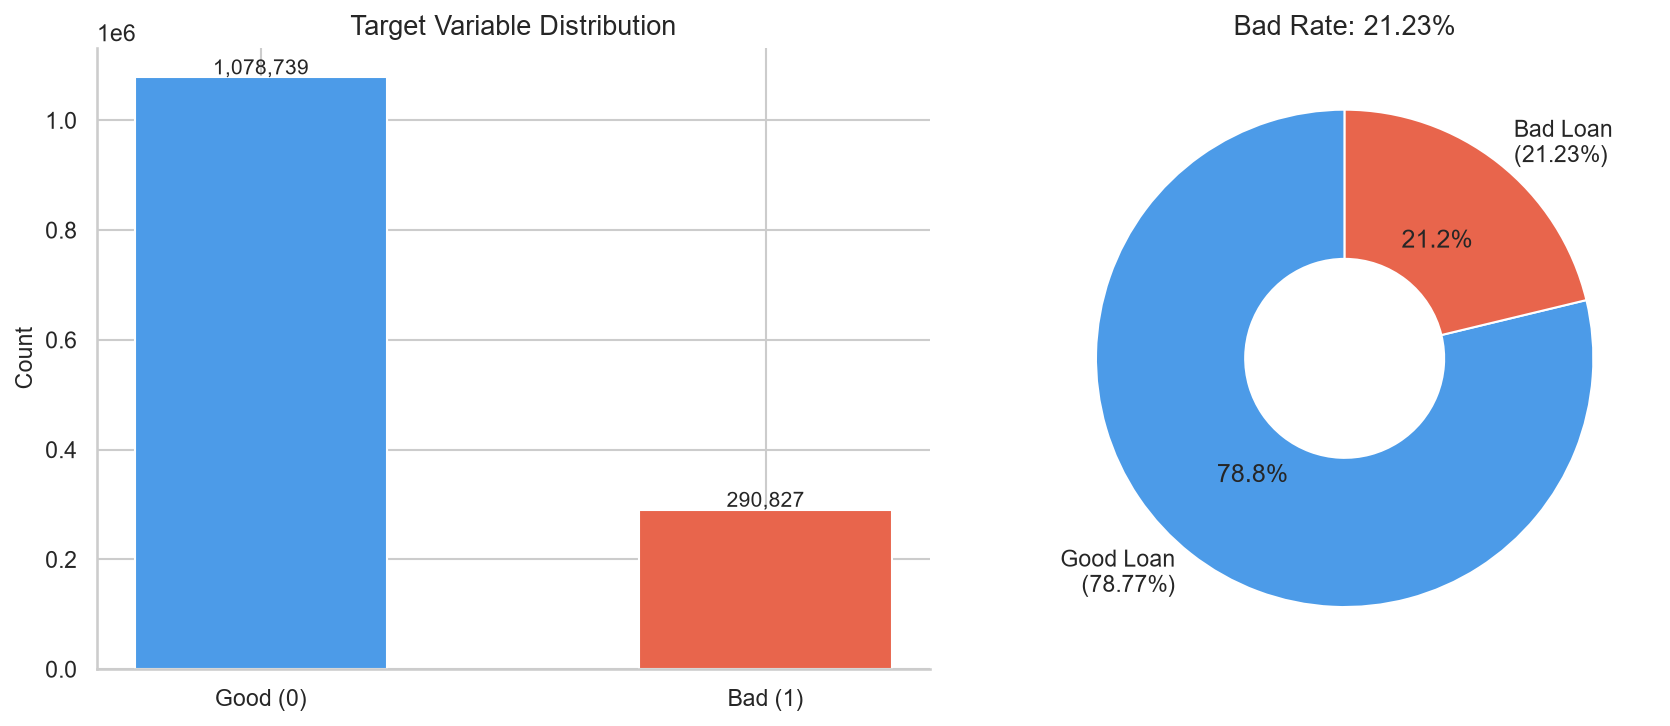

Class imbalance is moderate — will use class_weight='balanced' in modelling.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# counts
counts = df['is_bad'].value_counts().sort_index()
axes[0].bar(
    ['Good (0)', 'Bad (1)'],
    counts.values,
    color=['#4C9BE8', '#E8654C'],
    width=0.5
)
axes[0].set_title("Target Variable Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5000, f"{v:,}", ha='center', fontsize=10)

# percentages
axes[1].pie(
    counts.values,
    labels=['Good Loan\n(78.77%)', 'Bad Loan\n(21.23%)'],
    colors=['#4C9BE8', '#E8654C'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.6)
)
axes[1].set_title("Bad Rate: 21.23%")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_distribution.png", bbox_inches='tight')
plt.show()
print("Class imbalance is moderate — will use class_weight='balanced' in modelling.")

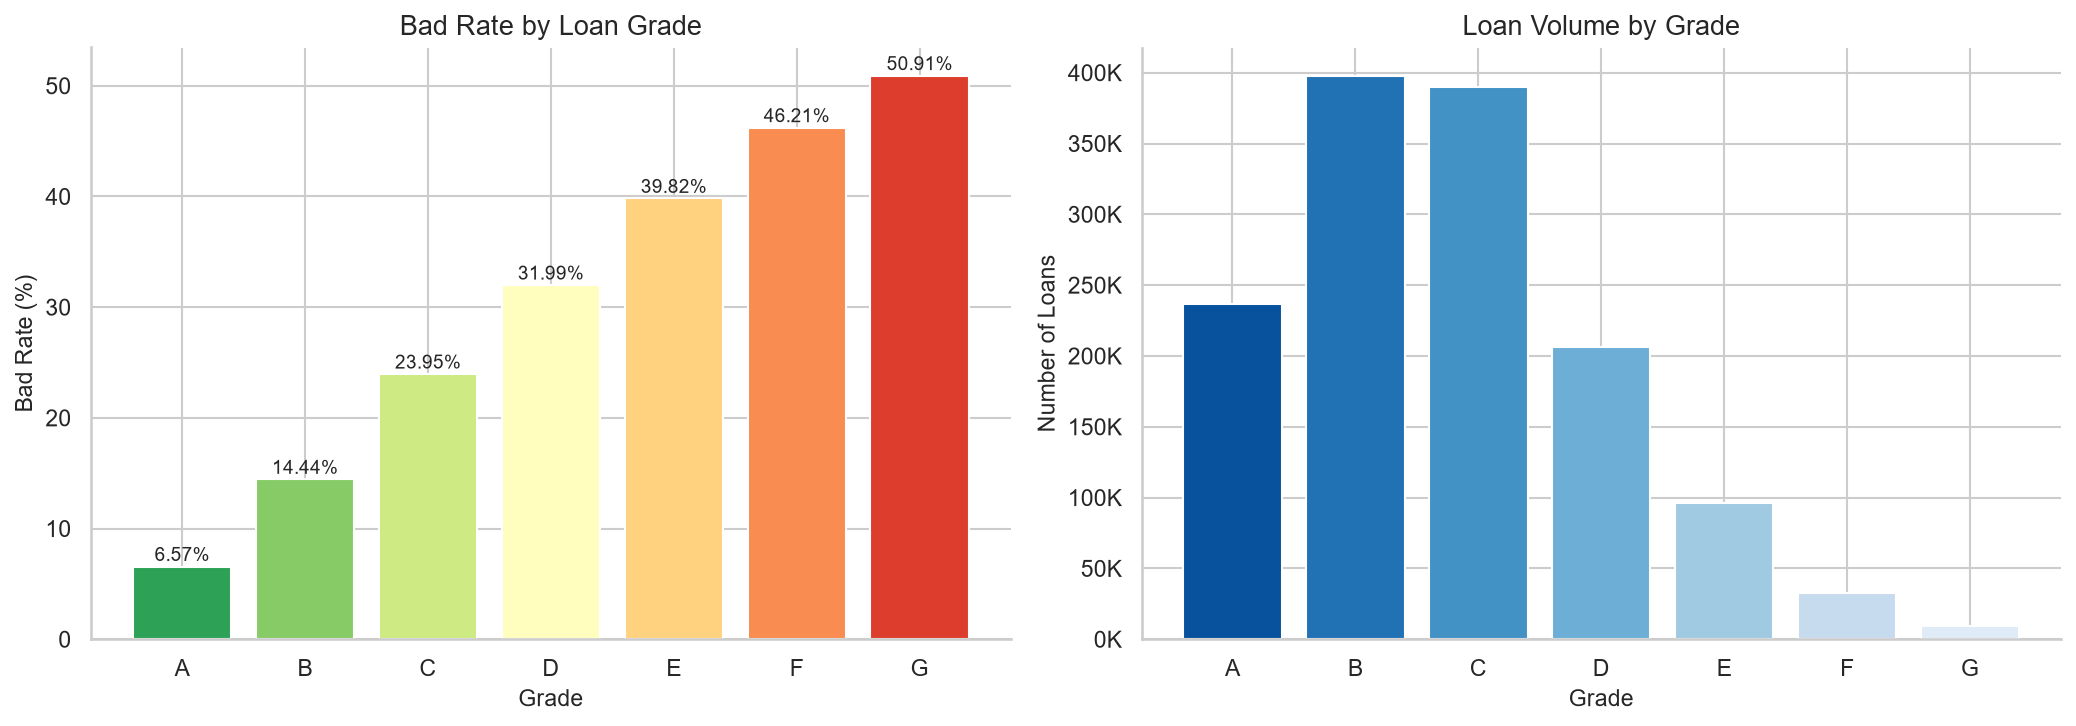

grade  total_loans  bad_loans  bad_rate_pct  avg_int_rate  avg_loan_amnt
    A       236515    15536.0          6.57          7.11        13901.0
    B       397890    57449.0         14.44         10.68        13265.0
    C       389877    93359.0         23.95         14.03        14231.0
    D       206418    66025.0         31.99         17.74        15295.0
    E        96358    38365.0         39.82         21.16        17577.0
    F        32946    15225.0         46.21         24.93        19060.0
    G         9562     4868.0         50.91         27.61        20421.0


In [9]:
grade_stats = conn.execute("""
    SELECT
        grade,
        COUNT(*)                        AS total_loans,
        SUM(is_bad)                     AS bad_loans,
        ROUND(AVG(is_bad) * 100, 2)     AS bad_rate_pct,
        ROUND(AVG(int_rate), 2)         AS avg_int_rate,
        ROUND(AVG(loan_amnt), 0)        AS avg_loan_amnt
    FROM staging.loans
    GROUP BY grade
    ORDER BY grade
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bad rate by grade
bars = axes[0].bar(
    grade_stats['grade'],
    grade_stats['bad_rate_pct'],
    color=sns.color_palette("RdYlGn_r", len(grade_stats))
)
axes[0].set_title("Bad Rate by Loan Grade")
axes[0].set_xlabel("Grade")
axes[0].set_ylabel("Bad Rate (%)")
for bar, val in zip(bars, grade_stats['bad_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{val}%", ha='center', fontsize=9)

# loan volume by grade
axes[1].bar(
    grade_stats['grade'],
    grade_stats['total_loans'],
    color=sns.color_palette("Blues_r", len(grade_stats))
)
axes[1].set_title("Loan Volume by Grade")
axes[1].set_xlabel("Grade")
axes[1].set_ylabel("Number of Loans")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

plt.tight_layout()
plt.savefig(FIG_DIR / "02_bad_rate_by_grade.png", bbox_inches='tight')
plt.show()

print(grade_stats.to_string(index=False))

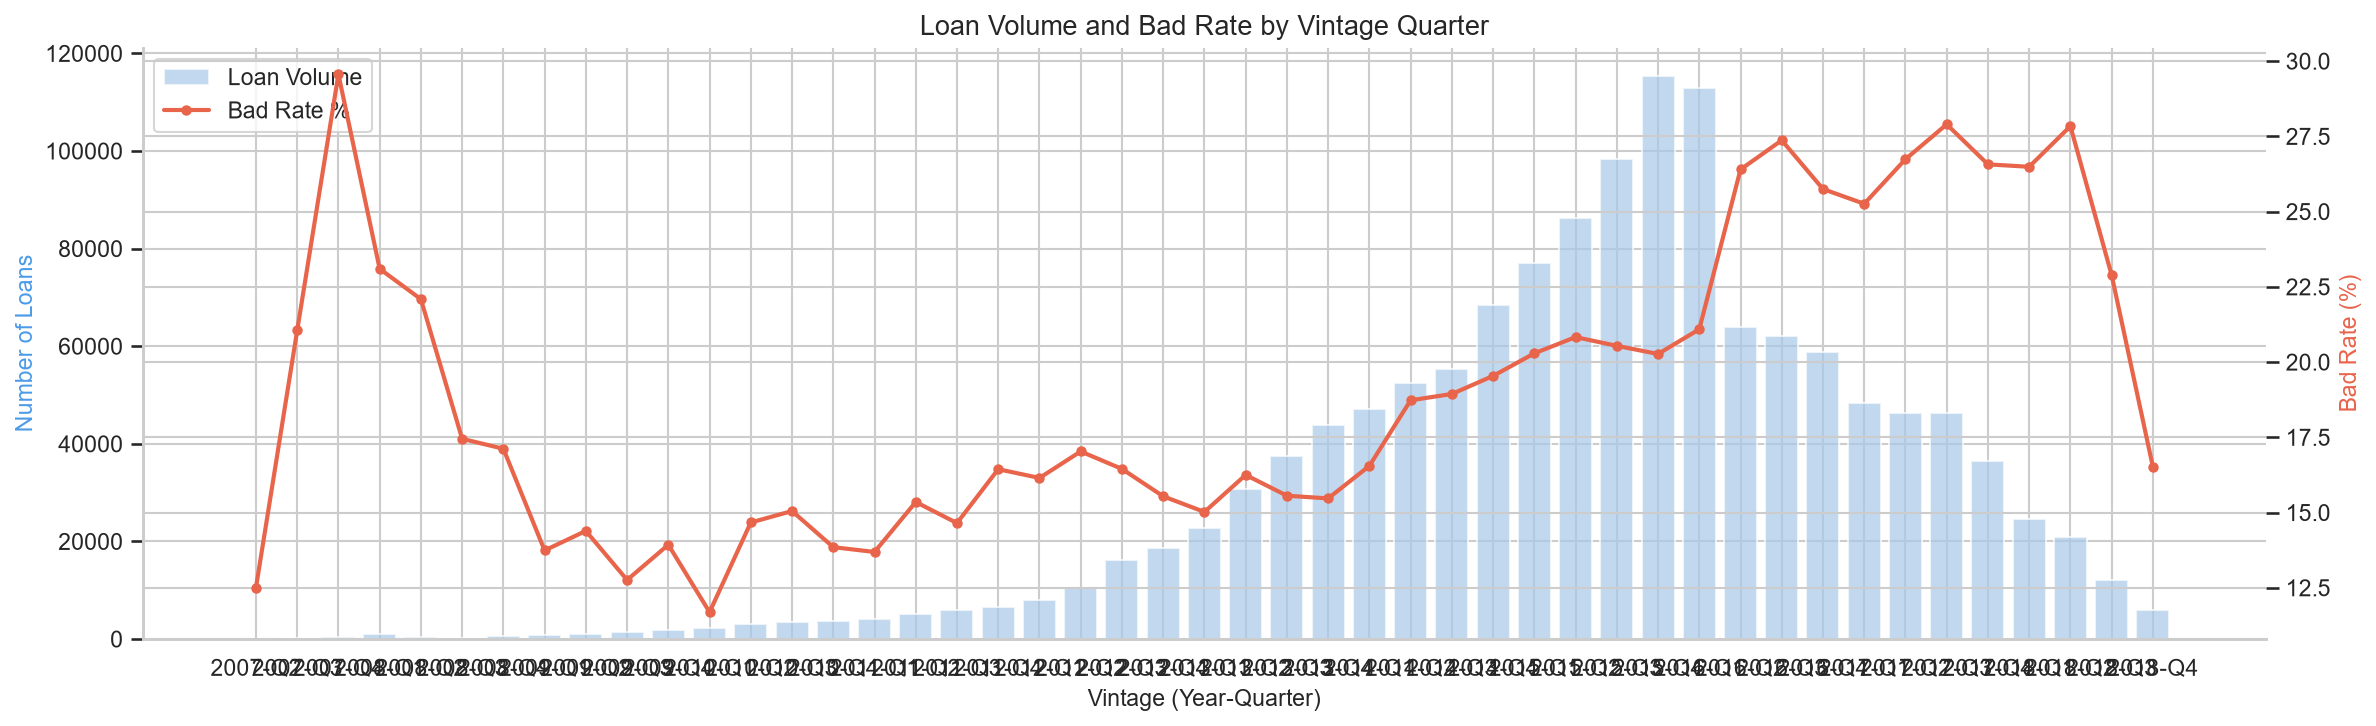

Note: 2016-2018 vintages show higher bad rates — loans haven't fully matured yet.


In [10]:
vintage = conn.execute("""
    SELECT
        vintage_year,
        vintage_quarter,
        CONCAT(CAST(vintage_year AS VARCHAR), '-Q',
               CAST(vintage_quarter AS VARCHAR))    AS vintage,
        COUNT(*)                                    AS total_loans,
        ROUND(AVG(is_bad) * 100, 2)                AS bad_rate_pct
    FROM staging.loans
    GROUP BY vintage_year, vintage_quarter, vintage
    ORDER BY vintage_year, vintage_quarter
""").df()

fig, ax1 = plt.subplots(figsize=(16, 5))

ax2 = ax1.twinx()

ax1.bar(vintage['vintage'], vintage['total_loans'],
        color='#A8C8E8', alpha=0.7, label='Loan Volume')
ax2.plot(vintage['vintage'], vintage['bad_rate_pct'],
         color='#E8654C', marker='o', linewidth=2,
         markersize=4, label='Bad Rate %')

ax1.set_xlabel("Vintage (Year-Quarter)")
ax1.set_ylabel("Number of Loans", color='#4C9BE8')
ax2.set_ylabel("Bad Rate (%)", color='#E8654C')
ax1.set_title("Loan Volume and Bad Rate by Vintage Quarter")

# rotate x labels
plt.xticks(rotation=90, fontsize=7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(FIG_DIR / "03_vintage_analysis.png", bbox_inches='tight')
plt.show()
print("Note: 2016-2018 vintages show higher bad rates — loans haven't fully matured yet.")

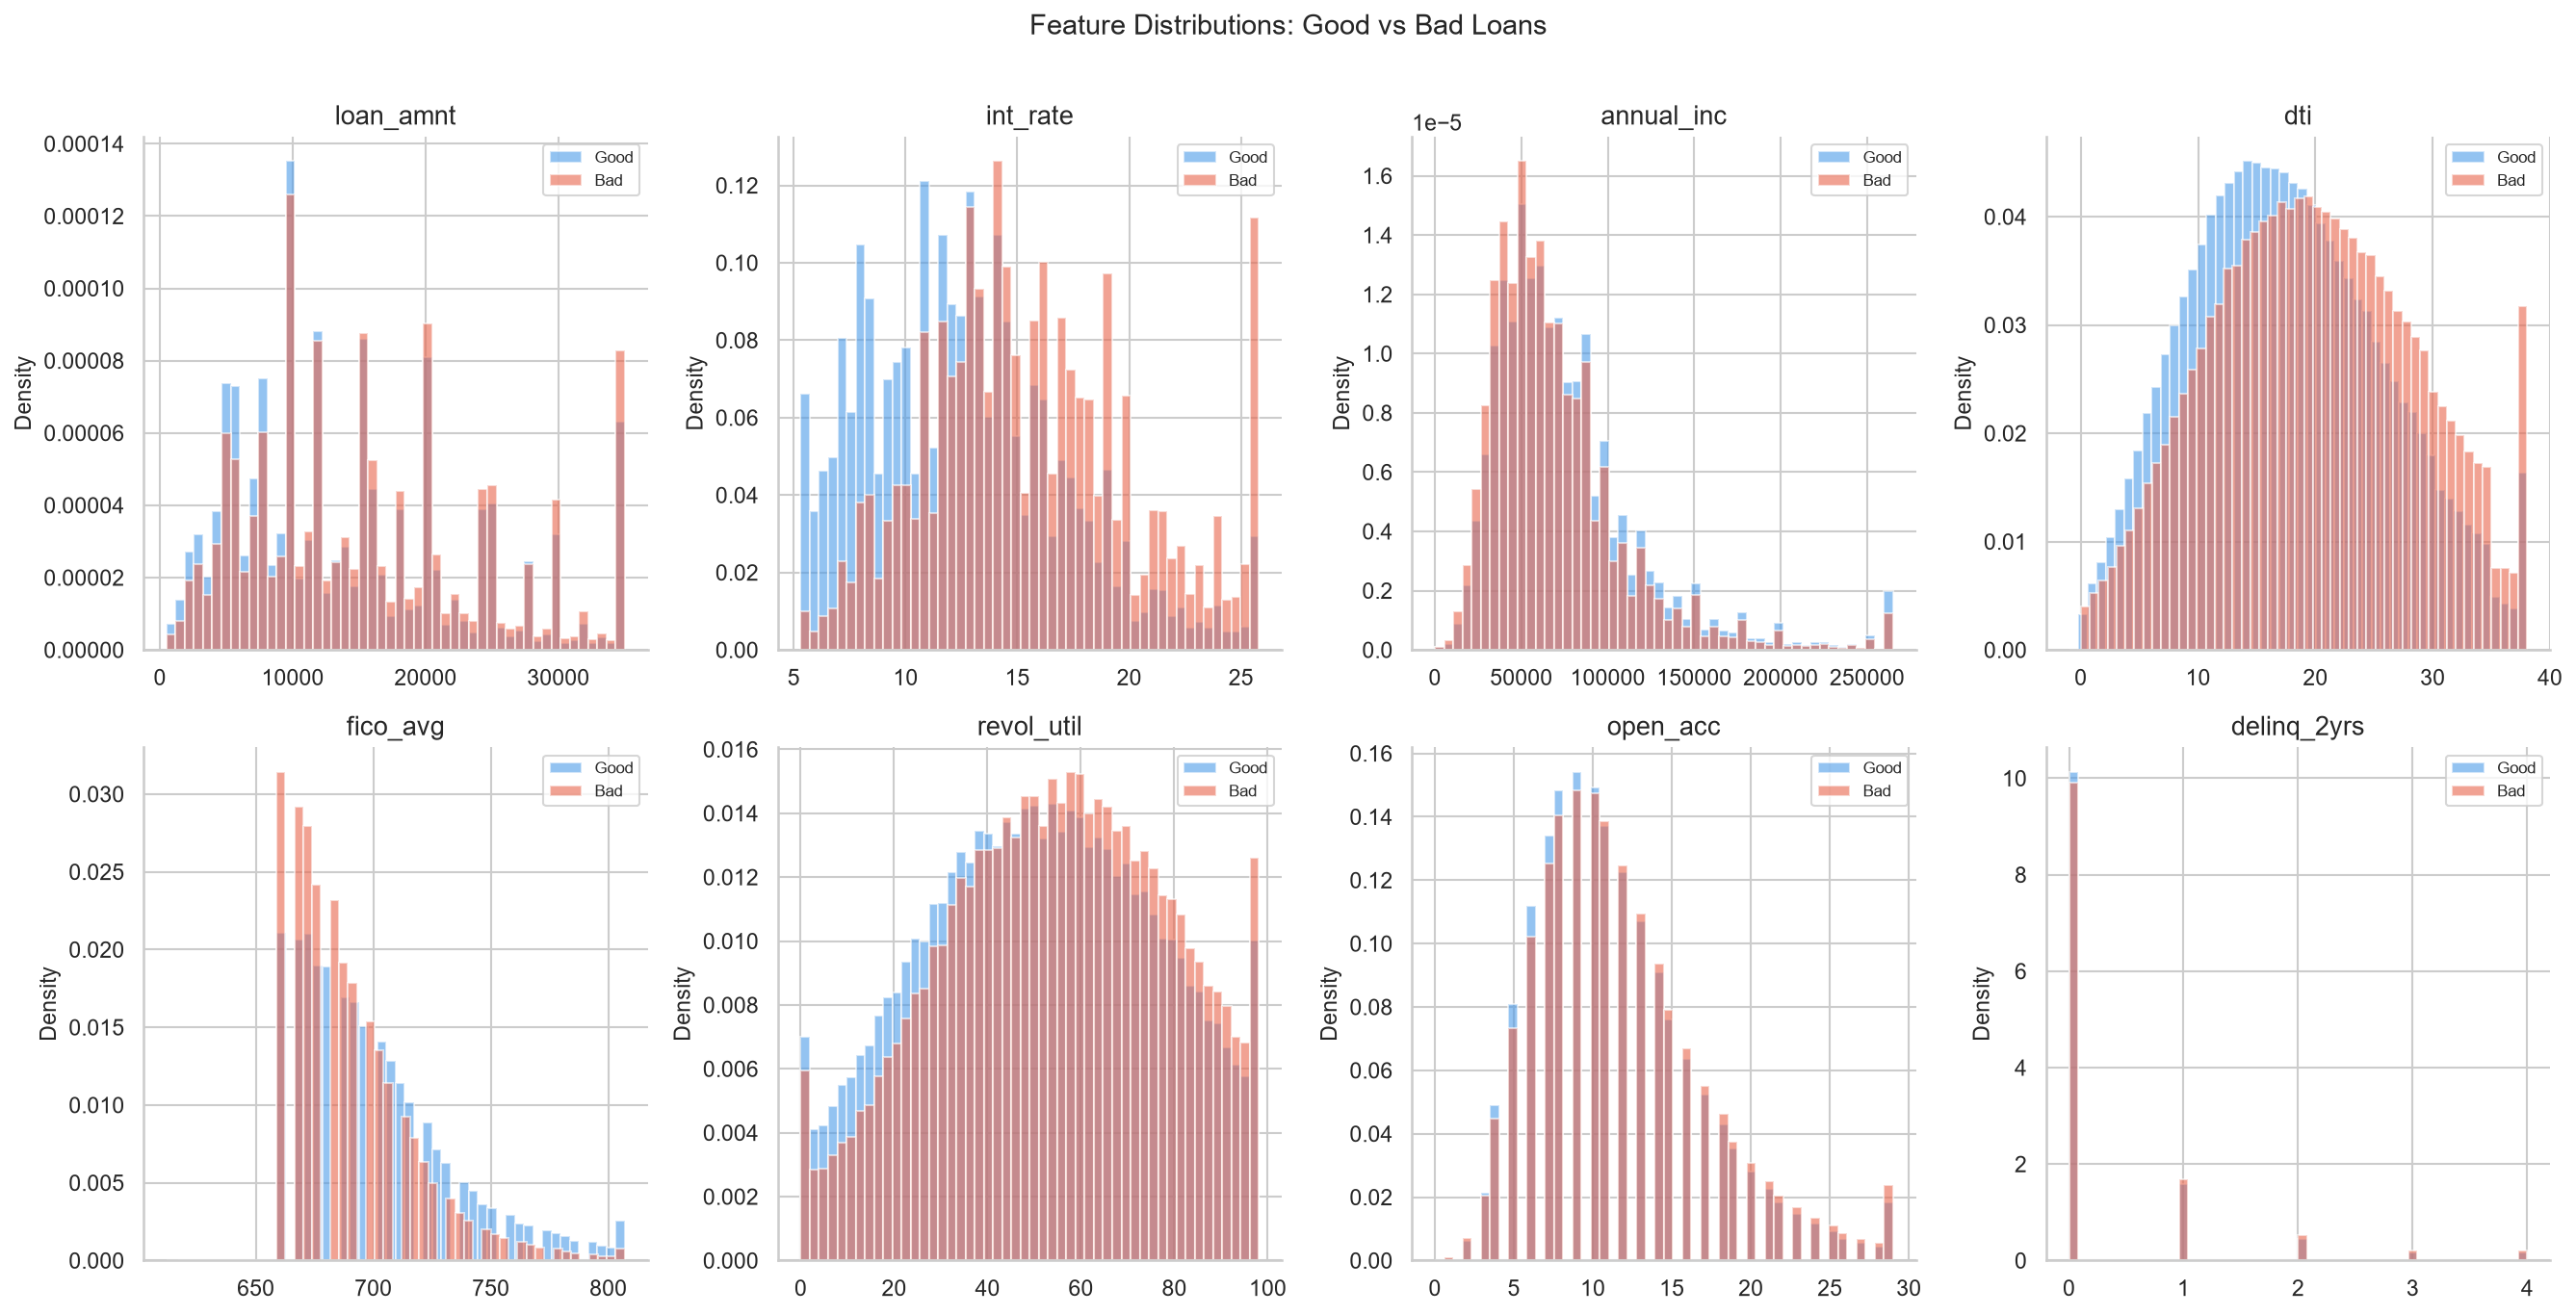

In [11]:
numeric_features = [
    'loan_amnt', 'int_rate', 'annual_inc', 'dti',
    'fico_avg', 'revol_util', 'open_acc', 'delinq_2yrs'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    data_good = df[df['is_bad'] == 0][col].dropna()
    data_bad  = df[df['is_bad'] == 1][col].dropna()

    # cap extreme outliers for plotting only
    cap = data_good.quantile(0.99)
    data_good = data_good.clip(upper=cap)
    data_bad  = data_bad.clip(upper=cap)

    axes[i].hist(data_good, bins=50, alpha=0.6,
                 color='#4C9BE8', label='Good', density=True)
    axes[i].hist(data_bad,  bins=50, alpha=0.6,
                 color='#E8654C', label='Bad',  density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel("Density")

plt.suptitle("Feature Distributions: Good vs Bad Loans", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_feature_distributions.png", bbox_inches='tight')
plt.show()

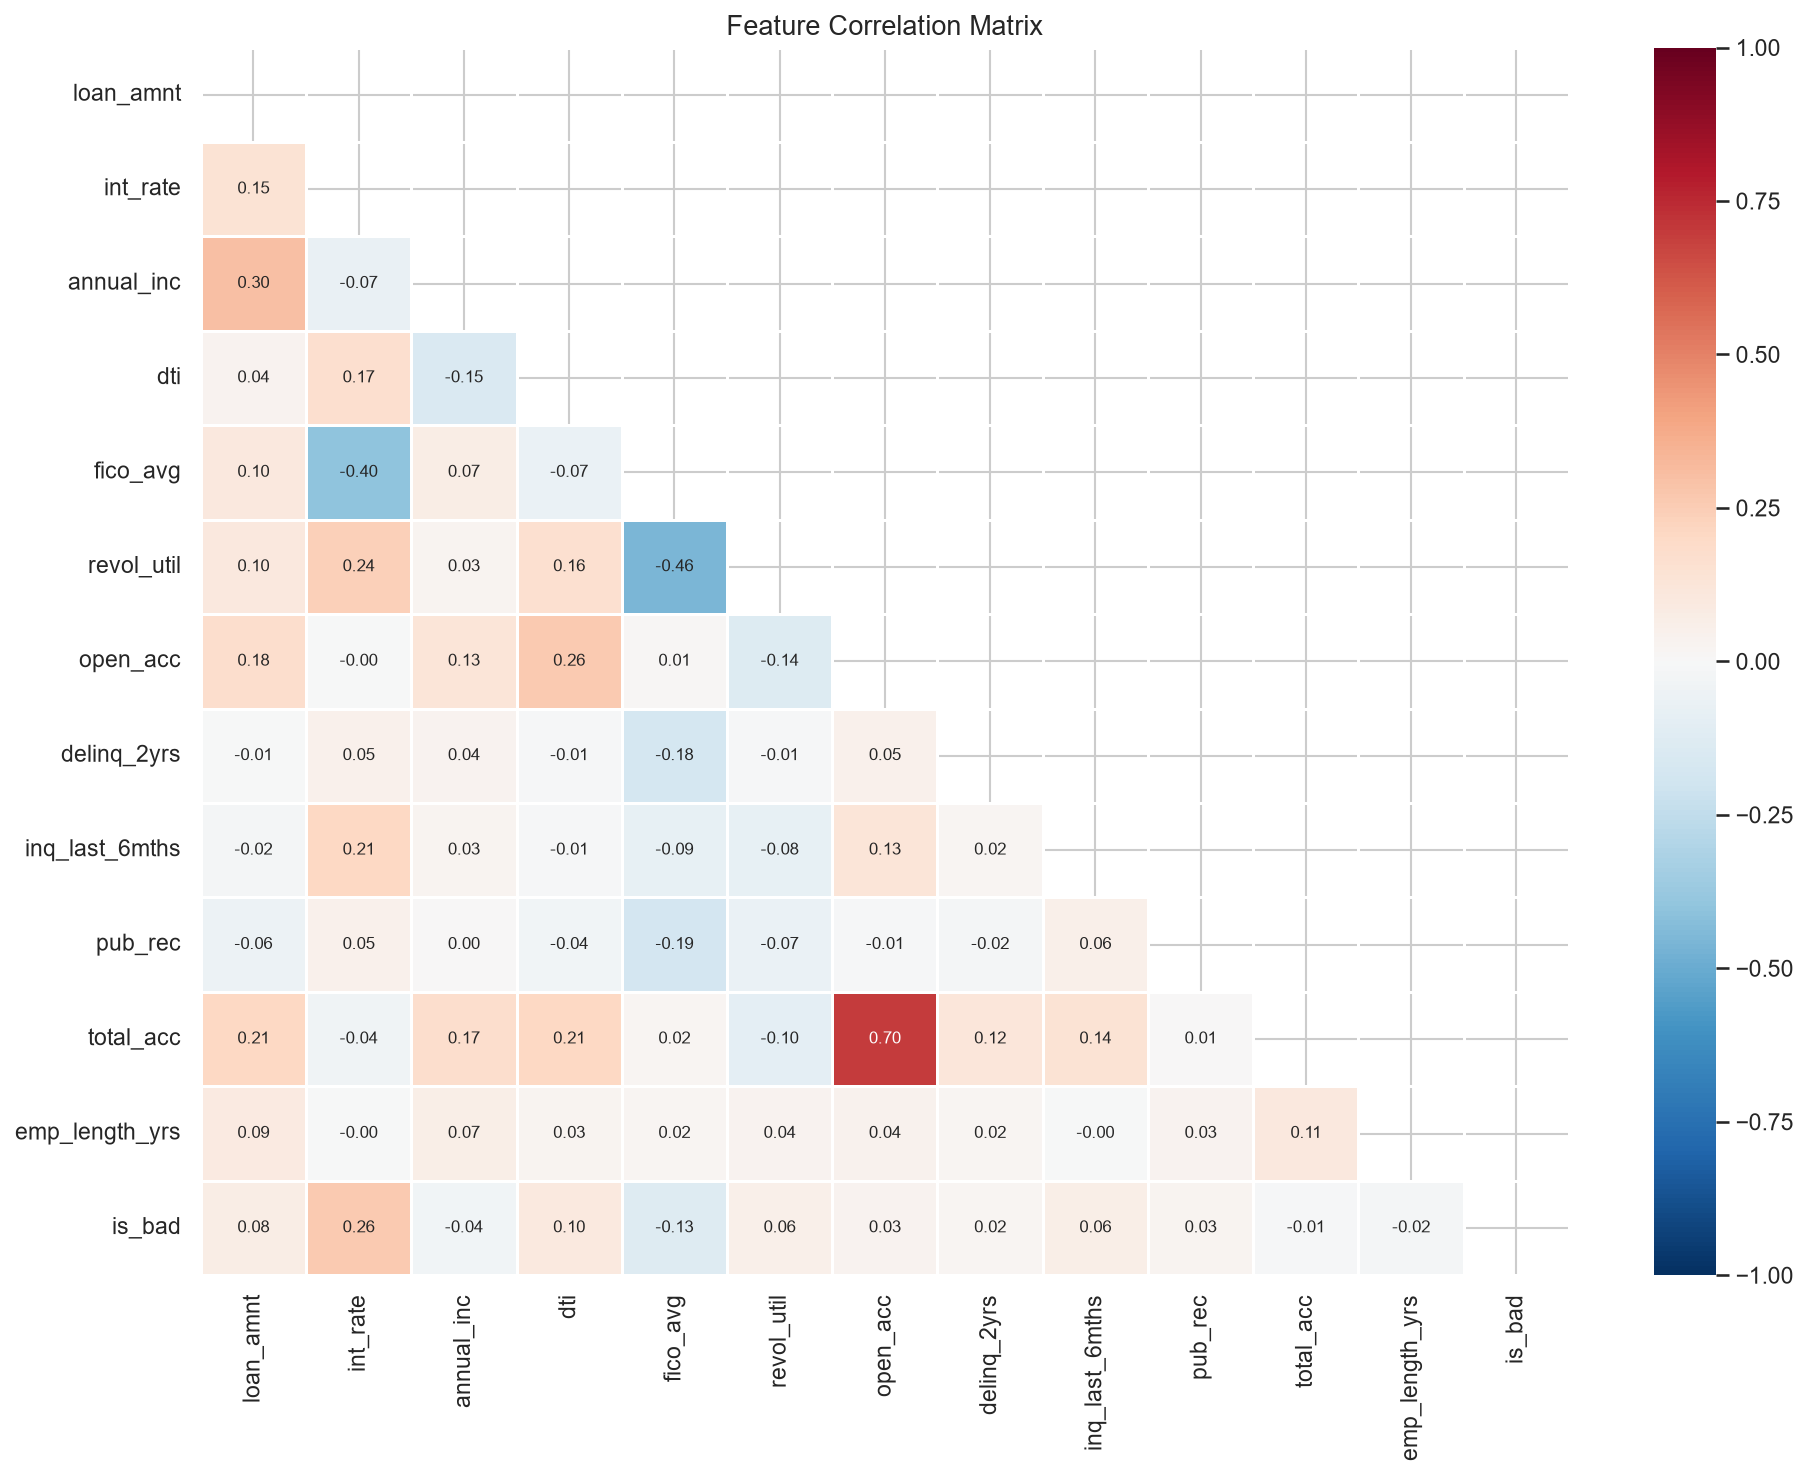


Top feature correlations with is_bad:
int_rate          0.2645
fico_avg         -0.1309
dti               0.0952
loan_amnt         0.0777
inq_last_6mths    0.0638
revol_util        0.0553
annual_inc       -0.0354
open_acc          0.0319
pub_rec           0.0260
delinq_2yrs       0.0203
emp_length_yrs   -0.0160
total_acc        -0.0126


In [12]:
corr_cols = [
    'loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_avg',
    'revol_util', 'open_acc', 'delinq_2yrs', 'inq_last_6mths',
    'pub_rec', 'total_acc', 'emp_length_yrs', 'is_bad'
]

corr_df = df[corr_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    annot_kws={"size": 8},
    linewidths=0.5
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_correlation_heatmap.png", bbox_inches='tight')
plt.show()

# print top correlations with target
target_corr = corr_matrix['is_bad'].drop('is_bad').sort_values(key=abs, ascending=False)
print("\nTop feature correlations with is_bad:")
print(target_corr.round(4).to_string())

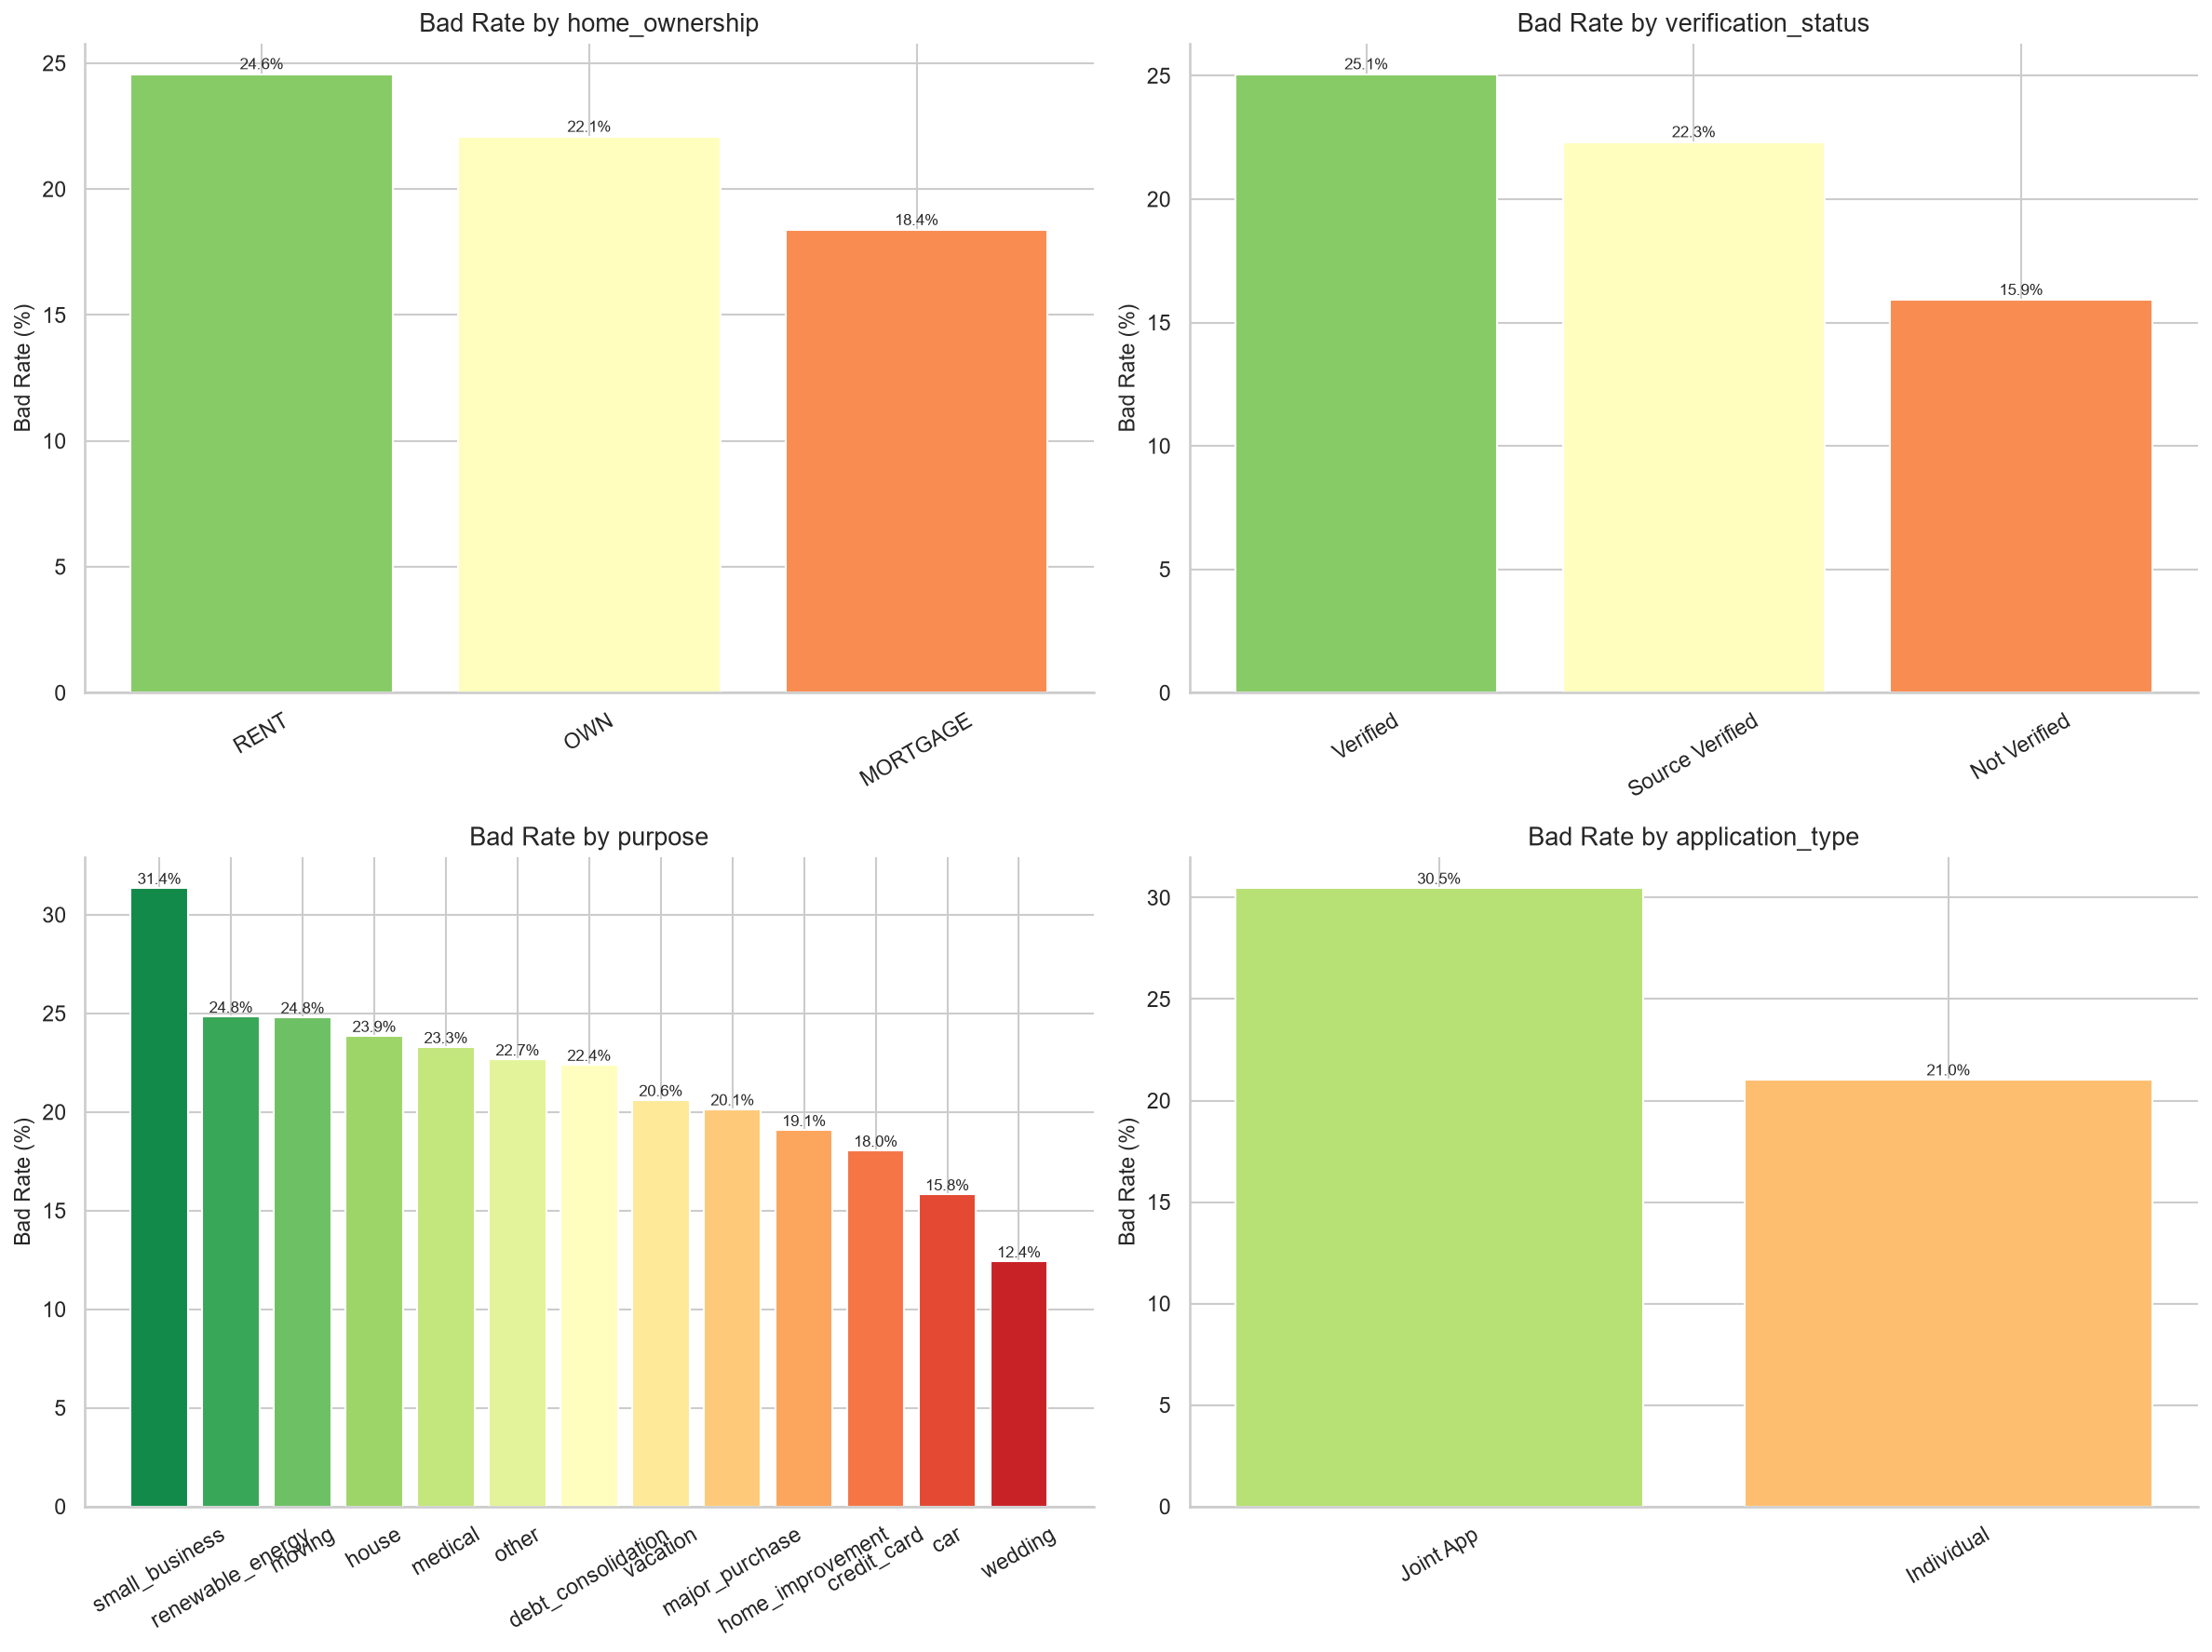

In [13]:
cat_features = ['home_ownership', 'verification_status', 'purpose', 'application_type']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    stats = (df.groupby(col)['is_bad']
               .agg(['mean', 'count'])
               .reset_index()
               .rename(columns={'mean': 'bad_rate', 'count': 'total'})
               .sort_values('bad_rate', ascending=False))

    # filter out tiny categories
    stats = stats[stats['total'] > 500]

    bars = axes[i].bar(
        stats[col],
        stats['bad_rate'] * 100,
        color=sns.color_palette("RdYlGn_r", len(stats))
    )
    axes[i].set_title(f"Bad Rate by {col}")
    axes[i].set_ylabel("Bad Rate (%)")
    axes[i].tick_params(axis='x', rotation=30)

    for bar, val in zip(bars, stats['bad_rate'] * 100):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.2,
                     f"{val:.1f}%", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "06_categorical_bad_rates.png", bbox_inches='tight')
plt.show()

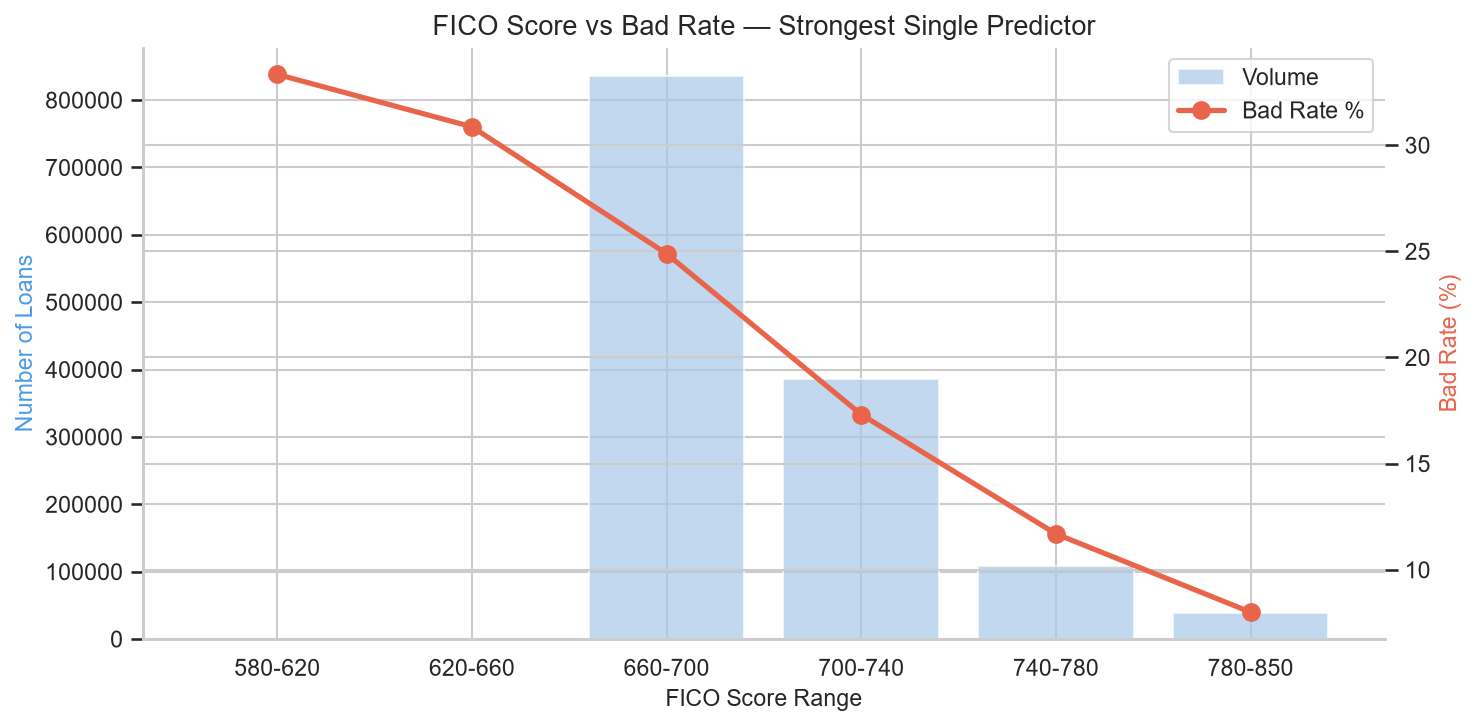

fico_bin  bad_rate  total
 580-620  0.333333      3
 620-660  0.308642    486
 660-700  0.248876 836285
 700-740  0.173123 385685
 740-780  0.116935 108394
 780-850  0.080051  38713


In [14]:
# bin FICO into ranges
df['fico_bin'] = pd.cut(
    df['fico_avg'],
    bins=[580, 620, 660, 700, 740, 780, 850],
    labels=['580-620', '620-660', '660-700', '700-740', '740-780', '780-850']
)

fico_stats = (df.groupby('fico_bin', observed=True)['is_bad']
                .agg(['mean', 'count'])
                .reset_index()
                .rename(columns={'mean': 'bad_rate', 'count': 'total'}))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bars = ax1.bar(fico_stats['fico_bin'].astype(str),
               fico_stats['total'],
               color='#A8C8E8', alpha=0.7, label='Volume')
ax2.plot(fico_stats['fico_bin'].astype(str),
         fico_stats['bad_rate'] * 100,
         color='#E8654C', marker='o',
         linewidth=2.5, markersize=8, label='Bad Rate %')

ax1.set_xlabel("FICO Score Range")
ax1.set_ylabel("Number of Loans", color='#4C9BE8')
ax2.set_ylabel("Bad Rate (%)", color='#E8654C')
ax1.set_title("FICO Score vs Bad Rate — Strongest Single Predictor")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.savefig(FIG_DIR / "07_fico_analysis.png", bbox_inches='tight')
plt.show()

print(fico_stats.to_string(index=False))

In [15]:
summary = conn.execute("""
    SELECT
        COUNT(*)                            AS total_loans,
        ROUND(AVG(is_bad) * 100, 2)         AS overall_bad_rate_pct,
        ROUND(AVG(loan_amnt), 0)            AS avg_loan_amount,
        ROUND(AVG(int_rate), 2)             AS avg_interest_rate,
        ROUND(AVG(fico_avg), 0)             AS avg_fico_score,
        ROUND(AVG(annual_inc), 0)           AS avg_annual_income,
        ROUND(AVG(dti), 2)                  AS avg_dti,
        MIN(vintage_year)                   AS first_vintage,
        MAX(vintage_year)                   AS last_vintage
    FROM staging.loans
""").df()

print("=" * 55)
print("DATASET SUMMARY — Credit Risk Scorecard Project")
print("=" * 55)
for col in summary.columns:
    print(f"  {col:<30} {summary[col].values[0]}")
print("=" * 55)
print(f"\n7 figures saved to: {FIG_DIR}")

DATASET SUMMARY — Credit Risk Scorecard Project
  total_loans                    1369566
  overall_bad_rate_pct           21.23
  avg_loan_amount                14449.0
  avg_interest_rate              13.28
  avg_fico_score                 698.0
  avg_annual_income              76250.0
  avg_dti                        18.3
  first_vintage                  2007
  last_vintage                   2018

7 figures saved to: C:\Users\Ayush\OneDrive\Desktop\CreditRiskScorecardDefaultPrediction\reports\figures
